# **IDS a Wrap: Culminating Workshop for IDS**

Instructors: Timothy Jonah Borromeo

Course: Introduction to Data Science

**Objectives:**

- To reinforce and apply the stages of the data science pipeline—from data acquisition to analysis—using a real-time and semi-structured dataset.
- To gain hands-on experience in collecting data from APIs using Python’s requests library, including authentication, handling JSON responses, and managing real-world API constraints.

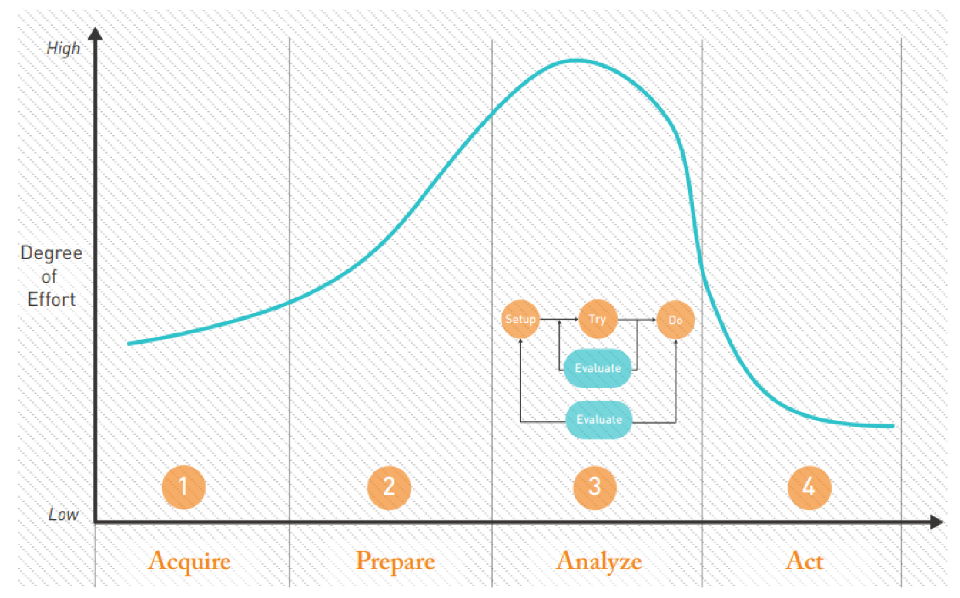

This image illustrates a familiar reality we've already discussed: the practical workflow of data science. It highlights four broad stages—**Acquire**, **Prepare**, **Analyze**, and **Act**—and shows how the **degree of effort** typically peaks during the analysis phase, where we encounter the most trial-and-error through cycles of setting up, trying, and evaluating different approaches.

> The pipeline provides the methodological structure to manage and extract value from data that is `large`, `fast`, `diverse`, `uncertain`, and `complex`.


However, as we’ve also acknowledged in our discussions, the data science pipeline is **not as simple or linear** as these four steps suggest. In practice, each stage contains a range of **more granular and specific methods**—from data cleaning, transformation, feature engineering, and model tuning, to interpreting results and communicating insights. The process is iterative, often messy, and highly dependent on the context and constraints of each project. This diagram serves as a helpful high-level summary, but the real work lies in the complexities within and between these stages.

### __Getting your Dataset (using API)__

But __first__!<br>
What is <b><u>API</u></b>?<br>

<p>
    
    An API (Application Programming Interface) is a tool to get information and services from other platforms or programs. It acts like a bridge between your code and the data you want to work with. In Data Science, APIs are widely used to fetch data from external sources, automate procedures, and even incorporate machine learning models into applications.

</p>

<font size=5px><b>Advantages of using API's to get Data</b></font>
- ___Real-Time Data___: Fetch the latest data whenever you need it.
- ___Automation___: Integrate data fetching into automated workflows.
- ___Large-Scale Access___: Retrieve data from large datasets that are difficult to download manually.

<font size=5px><b>Common Examples of APIs for Data</b></font>
- ___Weather APIs___: OpenWeatherMap, WeatherStack.
- ___Finance APIs___: Alpha Vantage, Yahoo Finance.
- ___Social Media APIs___: Twitter API, Facebook Graph API.
- ___Public Data___: NASA API, World Bank API.

<font size=5px><b>How does API work?</b></font>

- <b>Find the API</b>: &nbsp; Identify the API that provides the data you need. For example, if you need weather data, you might use the OpenWeatherMap API.
  
  
- <b>Get API Access</b>: &nbsp; Many APIs require an API key, which is like a password to access the API. Register for the API, and the service will provide you with an API key. 
  
  
- <b>Understand API Documentation</b>: &nbsp; Read the documentation to understand how to use the API, including endpoints (URLs for specific data), request methods (e.g., GET, POST), and required parameters (e.g., location or date).
  
  
- <b>Send a Request</b>: &nbsp; Use a programming language like Python to send a request to the API. Most APIs support the GET method to fetch data.
  
  
- <b>Receive and Process the Response</b>: &nbsp; The API sends back a response, typically in JSON or XML format. Parse and process the data for your use.

### __Getting our Data__

For this example, we will be getting our data from `Reddit.com` using `PRAW` or __<u>Python Reddit API Wrapper</u>__. 

***Python Reddit API Wrapper*** is a python module that provides a simple access to Reddit's API. PRAW is designed to be as simple to use as feasible and to adhere to all of Reddit's API requirements. Similiar to Reddit API, PRAW also requires authentication such as the `client_id`, `client_secret_key`, and `user agent`, which are important in accessing the API.


**Pre-workshop questions to ponder:**

1. How will we collect the data?
2. What challenges might we face when cleaning or organizing this data?
3. How can we turn raw game data into valuable insights?
<!-- 3. What questions can we ask or answer with this data?
4. How can AI tools like ChatGPT assist us throughout the process?
5. How can we turn raw game data into valuable insights? -->

## **Basic Concepts**

<center><img src="https://i.redd.it/561zhyyucky71.jpg" width="350px"></center>

To get the most out of this workshop, it's important to have a basic grasp of the following concepts and tools, especially since we’ll be working directly with a real-world API:

1. **API (Application Programming Interface)**
2. **Endpoint**
3. **Base URL**
4. **Request**
5. **Request Methods**
6. **Headers**
7. **Authentication**
8. **API Token**
9. **Status Code**
10. **JSON**
11. **Query Parameters**

## Import Necessary Libraries

In [8]:
import pandas as pd
import numpy as np

import praw # ----  pip install praw or !pip install praw (if in your jupyter notebook) ---- 
import requests
from requests.exceptions import ConnectionError

from tqdm.notebook import tqdm
tqdm.pandas()

from IPython.display import Markdown
from dotenv import load_dotenv
import os

import warnings
warnings.filterwarnings('ignore')

## Connection Status

In [9]:
"""
    This is to test if we can access reddit.com prior to getting our data
    using requests. 
"""

try:
    session = requests.Session()
    url = 'https://reddit.com'
    connection = session.get(url)
    if connection.status_code != 202 and connection.status_code != 200:
        display(Markdown(f"<b>Unexpected status code</b>: {connection.status_code} {connection.reason}"))
    else:
        display(Markdown(f"<b>Success</b>: <u><i>{connection.status_code} {connection.reason}</u></i>"))
except ConnectionError as e:
    display(Markdown(f"<b>Connection failed</b>: {e}"))

<b>Success</b>: <u><i>200 OK</u></i>

To protect your API key and avoid accidentally sharing it (e.g., when uploading code to GitHub), it's good practice to **store sensitive information in a `.env` file**.

1. **Install the `python-dotenv` library** (if not already installed):
   ```bash
   pip install python-dotenv
   ```
   
2. **Create a `.env` file** in the **same directory** as your Jupyter notebook or Python script.


3. Inside the `.env` file, store your API key like this:
   ```
   API_TOKEN=your_actual_api_key_here

>> This is a sample of making an .env file.

In [10]:
"""
    Here we get our client_id and secret_key from our .env file.
"""
load_dotenv()

client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('SECRET_KEY')
user_agent = os.getenv('USER_AGENT')

In [11]:
"""
    We then access reddit using PRAW.

"""

try: 
    reddit = praw.Reddit(client_id= client_id,
                     client_secret= client_secret,
                     user_agent=user_agent)
except Exception as e:
    print(f'Error using PRAW - {e}')

In [ ]:
# """
#     We then create a list to store the data for each reddit post. In this case, we are using the subreddit `r/all`. 
#     Then we iterate over the reddit posts by fetching the top 2500 posts filtered by `hot`. // You can change the limit if you want to.

# """
# hot_posts = list(reddit.subreddit('science').hot(limit=2500))
# data = []

# for submission in tqdm(hot_posts, desc="Fetching submissions", unit="post"):
#     # submission.comments.replace_more(limit=1)
#     # comments = [comment.body for comment in submission.comments.list()]
#     data.append([
#         submission.title,
#         submission.score,
#         submission.author,
#         submission.upvote_ratio,
#         submission.num_comments,
#         submission.over_18
#         # comments
#     ])
    
# df = pd.DataFrame(data, columns=['title', 'upvotes', 'author', 
#                                  'upvote_ratio','num_comments', 'is_nsfw'])
# df

Fetching submissions:   0%|          | 0/1000 [00:00<?, ?post/s]

,title,upvotes,author,upvote_ratio,num_comments,is_nsfw
0,Feeling empty after finishing a video game (po...,11419,mvea,0.95,876,False
1,"A healthy brain, achieved through exercise, a ...",1953,sr_local,0.98,25,False
2,Even mild blows to the head disrupt the microb...,856,Jxntb733,0.98,23,False
3,1 in 3 people believe they don’t have to seek ...,6016,mvea,0.96,311,False
4,Recent political discussions often focus on wo...,3190,FreeHugs23,0.90,317,False
...,...,...,...,...,...,...
995,CRISPR makes enhanced cancer-fighting immune c...,240,IWantPizza555,0.98,4,False
996,The earliest clay ornaments ever found outside...,102,sibun_rath,0.74,28,False
997,Ground penetrating radar observations of ancie...,75,Appropriate-Push-668,0.98,1,False
998,New psychology research reveals the cognitive ...,482,Doug24,0.96,105,False


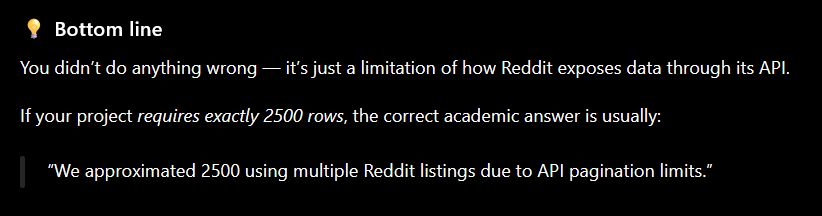

💡 Bottom line

You didn’t do anything wrong — it’s just a limitation of how Reddit exposes data through its API.

If your project requires exactly 2500 rows, the correct academic answer is usually:

“We approximated 2500 using multiple Reddit listings due to API pagination limits.”

In [15]:
hot_posts = list(reddit.subreddit('science').hot(limit=2500))
data = []

for submission in tqdm(hot_posts, desc="Fetching submissions", unit="post"):

    data.append([
        submission.title,
        submission.score,
        submission.author,
        submission.upvote_ratio,
        submission.num_comments,
        submission.over_18,
        submission.link_flair_text  # 👈 NEW COLUMN
    ])

df = pd.DataFrame(
    data,
    columns=[
        'title',
        'upvotes',
        'author',
        'upvote_ratio',
        'num_comments',
        'is_nsfw',
        'flair'
    ]
)

df

Fetching submissions:   0%|          | 0/1000 [00:00<?, ?post/s]

,title,upvotes,author,upvote_ratio,num_comments,is_nsfw,flair
0,Feeling empty after finishing a video game (po...,11614,mvea,0.95,888,False,Psychology
1,"A healthy brain, achieved through exercise, a ...",2027,sr_local,0.98,26,False,Neuroscience
2,Even mild blows to the head disrupt the microb...,950,Jxntb733,0.98,25,False,Health
3,1 in 3 people believe they don’t have to seek ...,6045,mvea,0.96,313,False,Psychology
4,Recent political discussions often focus on wo...,3215,FreeHugs23,0.90,319,False,Psychology
...,...,...,...,...,...,...,...
995,CRISPR makes enhanced cancer-fighting immune c...,237,IWantPizza555,0.98,4,False,Cancer
996,The earliest clay ornaments ever found outside...,108,sibun_rath,0.74,28,False,Anthropology
997,Ground penetrating radar observations of ancie...,75,Appropriate-Push-668,0.98,1,False,Astronomy
998,New psychology research reveals the cognitive ...,474,Doug24,0.96,105,False,Psychology


## Lets look at our DataFrame!

In [16]:
display(df.info(), df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1000 non-null   object 
 1   upvotes       1000 non-null   int64  
 2   author        961 non-null    object 
 3   upvote_ratio  1000 non-null   float64
 4   num_comments  1000 non-null   int64  
 5   is_nsfw       1000 non-null   bool   
 6   flair         1000 non-null   object 
dtypes: bool(1), float64(1), int64(2), object(3)
memory usage: 48.0+ KB


None

,upvotes,upvote_ratio,num_comments
count,1000.000000,1000.000000,1000.000000
mean,2301.314000,0.924910,138.096000
std,4109.450312,0.096196,284.935932
min,0.000000,0.230000,1.000000
25%,128.500000,0.910000,5.000000
50%,610.000000,0.960000,27.000000
75%,2619.000000,0.980000,136.000000
max,33569.000000,0.990000,2531.000000


# Activity

<div class="ds-markdown ds-assistant-message-main-content" style="--ds-md-zoom: 1.143;"><p class="ds-markdown-paragraph"><hr><h3><strong><span class="">Instruction: Analytical Exploration of Reddit Data</span></strong></h3><p class="ds-markdown-paragraph"><em><span class="">(using the columns: title, upvotes, author, upvote_ratio, num_comments, is_nsfw)</span></em></p><p class="ds-markdown-paragraph"><span class="">You are tasked with analyzing Reddit data collected via the </span><strong><span class="">Reddit API (PRAW)</span></strong><span class="">. Your dataset contains submissions with the following attributes:</span></p><ul><li><p class="ds-markdown-paragraph"><code>title</code><span class=""> – post title</span></p></li><li><p class="ds-markdown-paragraph"><code>upvotes</code><span class=""> – net score (upvotes minus downvotes)</span></p></li><li><p class="ds-markdown-paragraph"><code>author</code><span class=""> – username of the poster</span></p></li><li><p class="ds-markdown-paragraph"><code>upvote_ratio</code><span class=""> – proportion of upvotes (0 to 1)</span></p></li><li><p class="ds-markdown-paragraph"><code>num_comments</code><span class=""> – total number of comments</span></p></li><li><p class="ds-markdown-paragraph"><code>is_nsfw</code><span class=""> – boolean indicating mature content</span></p></li></ul><p class="ds-markdown-paragraph"><span class="">Using this data (e.g., from a specific subreddit or across multiple subreddits), your goal is to uncover meaningful insights about user engagement and content characteristics.</span></p><hr><h2><strong><span class="">Tasks</span></strong></h2><h3><span class="">1. Formulate Analytical Questions</span></h3><p class="ds-markdown-paragraph"><span class="">Develop </span><strong><span class="">3–4 analytical questions</span></strong><span class=""> that can be answered using only the six columns above. Examples include:</span></p><ul><li><p class="ds-markdown-paragraph"><span class="">How does the </span><strong><span class="">upvote ratio</span></strong><span class=""> differ between </span><strong><span class="">NSFW</span></strong><span class=""> and </span><strong><span class="">non‑NSFW</span></strong><span class=""> posts?</span></p></li><li><p class="ds-markdown-paragraph"><span class="">Is there a correlation between </span><strong><span class="">upvotes</span></strong><span class=""> and </span><strong><span class="">number of comments</span></strong><span class="">? Does this relationship change when controlling for </span><code>upvote_ratio</code><span class="">?</span></p></li><li><p class="ds-markdown-paragraph"><span class="">Which </span><strong><span class="">authors</span></strong><span class=""> produce the most consistently high‑upvoted content? (e.g., average upvotes per post)</span></p></li><li><p class="ds-markdown-paragraph"><span class="">Does a higher </span><code>upvote_ratio</code><span class=""> always mean more upvotes? Or do some posts with moderate ratio still receive high comment counts?</span></p></li><li><p class="ds-markdown-paragraph"><span class="">What is the distribution of </span><strong><span class="">upvotes</span></strong><span class=""> and </span><strong><span class="">comment counts</span></strong><span class=""> across different authors (e.g., power users vs. occasional posters)?</span></p></li></ul><p class="ds-markdown-paragraph"><span class="">Feel free to use AI tools to refine your questions or hypothesize about expected patterns.</span></p><h3><span class="">2. Analyze the Data</span></h3><p class="ds-markdown-paragraph"><span class="">Use Python with </span><strong><span class="">pandas</span></strong><span class="">, </span><strong><span class="">seaborn</span></strong><span class="">, and </span><strong><span class="">matplotlib</span></strong><span class=""> to explore the data. Consider:</span></p><ul><li><p class="ds-markdown-paragraph"><strong><span class="">Descriptive statistics</span></strong><span class="">: mean, median, spread of </span><code>upvotes</code><span class="">, </span><code>num_comments</code><span class="">, </span><code>upvote_ratio</code><span class=""> – segmented by </span><code>is_nsfw</code><span class="">.</span></p></li><li><p class="ds-markdown-paragraph"><strong><span class="">Correlation analysis</span></strong><span class="">:</span></p><ul><li><p class="ds-markdown-paragraph"><span class="">Pearson / Spearman correlation between </span><code>upvotes</code><span class=""> and </span><code>num_comments</code><span class="">.</span></p></li><li><p class="ds-markdown-paragraph"><span class="">Relationship between </span><code>upvote_ratio</code><span class=""> and </span><code>upvotes</code><span class=""> (scatter plot with trend line).</span></p></li></ul></li><li><p class="ds-markdown-paragraph"><strong><span class="">Author‑level aggregation</span></strong><span class="">:</span></p><ul><li><p class="ds-markdown-paragraph"><span class="">Group by </span><code>author</code><span class=""> to compute average upvotes, average comment count, post frequency.</span></p></li><li><p class="ds-markdown-paragraph"><span class="">Identify top authors by different metrics (e.g., highest median upvotes).</span></p></li></ul></li><li><p class="ds-markdown-paragraph"><strong><span class="">Binary comparison</span></strong><span class=""> (NSFW vs. non‑NSFW):</span></p><ul><li><p class="ds-markdown-paragraph"><span class="">Use boxplots or violin plots to compare distributions of </span><code>upvotes</code><span class=""> and </span><code>num_comments</code><span class="">.</span></p></li></ul></li></ul><h3><span class="">3. Visualize Your Findings</span></h3><p class="ds-markdown-paragraph"><span class="">Create clear, informative visuals that support your analysis:</span></p><ul><li><p class="ds-markdown-paragraph"><strong><span class="">Bar chart</span></strong><span class=""> – Average upvotes per author (top 10 authors by volume or by performance).</span></p></li><li><p class="ds-markdown-paragraph"><strong><span class="">Boxplots</span></strong><span class=""> – Upvote ratio distribution split by </span><code>is_nsfw</code><span class="">.</span></p></li><li><p class="ds-markdown-paragraph"><strong><span class="">Scatter plots</span></strong><span class=""> – Upvotes vs. num_comments, colored by </span><code>is_nsfw</code><span class=""> or sized by </span><code>upvote_ratio</code><span class="">.</span></p></li><li><p class="ds-markdown-paragraph"><strong><span class="">Histograms</span></strong><span class=""> – Distribution of upvotes (log‑scale if highly skewed).</span></p></li><li><p class="ds-markdown-paragraph"><strong><span class="">Heatmap</span></strong><span class=""> – Correlation matrix of numerical columns (</span><code>upvotes</code><span class="">, </span><code>upvote_ratio</code><span class="">, </span><code>num_comments</code><span class="">).</span></p></li></ul><h3><span class="">4. Present Your Results</span></h3><p class="ds-markdown-paragraph"><span class="">Prepare a </span><strong><span class="">3–5 minute presentation</span></strong><span class=""> covering:</span></p><ul><li><p class="ds-markdown-paragraph"><span class="">Your </span><strong><span class="">analytical questions</span></strong><span class=""> and why they matter for understanding Reddit engagement.</span></p></li><li><p class="ds-markdown-paragraph"><strong><span class="">Methods</span></strong><span class=""> – how you fetched the data (e.g., from </span><code>reddit.subreddit('all').hot()</code><span class="">) and cleaned/analyzed it.</span></p></li><li><p class="ds-markdown-paragraph"><strong><span class="">Key findings</span></strong><span class=""> – e.g., “NSFW posts have a wider spread of upvote ratios but lower median upvotes,” or “The correlation between upvotes and comment count is moderate (r=0.6) but weaker for very high upvote posts.”</span></p></li><li><p class="ds-markdown-paragraph"><strong><span class="">Implications</span></strong><span class=""> – What these insights suggest for content creators, moderators, or marketers (e.g., NSFW tagging affects engagement, encouraging comments may boost upvotes, etc.).</span></p></li></ul><p class="ds-markdown-paragraph"><strong><span class="">Be ready to share your results</span></strong><span class=""> with the class and discuss how your analysis could inform Reddit community strategies.</span></p>

## What are subreddits?

Subreddits are a dedicated, user-created community or discussion forum in Reddit, focusing on a specified topic. Either sports, gaming, news, or even just by asking each other questions to create converations between users(or redditors, as they call themselves.) These subreddits even have unique rules, moderated by users, and its own community culture. 

For each group, you must only choose 1 subreddit to analyze (1 Group: 1 Subreddit):

1. **r/AskReddit**
2. **r/funny**
3. **r/ShowerThoughts**
4. **r/todayilearned**
5. **r/memes**
6. **r/news**
7. **r/science**